# PC algorithm results

Check how well the discovered causal links match the true connections.

## Code setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os

# Add modules to path:
import sys
sys.path.append('../')  # path to dir containing modules
from modules.utils_dag import categorise_edges_vs_true, \
    make_legend_entry_for_line, make_formatting_for_edges, \
    plot_comparative_dag_networkx, plot_matrix_edge_comparison

## Load discovered effects

Load in the discovered effect dataframes from a previous notebook.

In [2]:
path_save = '01_pc'
file_names = [f for f in os.listdir(path_save)
              if f.startswith('discovered') & f.endswith('csv')]
variation_names = [f.replace('discovered_', '').replace('.csv', '')
                   for f in file_names]

file_names

['discovered_alpha002.csv', 'discovered_default.csv']

In [3]:
dict_disc = {}
for f, file_name in enumerate(file_names):
    dict_disc[variation_names[f]] = pd.read_csv(
        os.path.join(path_save, file_name), index_col=0)

Check one of them:

In [4]:
dict_disc['default']

,year,age,male,afib,warfarin,shoe_size,nihss,thrombolysis_time,thrombolysis,mortality_prob_no_treatment,mortality_probability,ethnicity_asian,ethnicity_black,ethnicity_white
year,0,0,0,0,0,0,0,0,0,1,0,0,0,0
age,0,0,0,1,0,0,1,0,0,1,0,0,0,0
male,0,0,0,0,0,0,0,0,0,1,1,0,0,0
afib,0,1,0,0,1,0,0,0,0,1,0,0,0,0
warfarin,0,0,0,1,0,0,0,0,1,0,0,0,0,0
shoe_size,0,0,0,0,0,0,0,0,1,0,0,0,0,0
nihss,0,0,0,0,0,0,0,0,0,1,0,0,0,0
thrombolysis_time,0,0,0,0,0,0,0,0,0,0,1,0,0,0
thrombolysis,0,0,0,0,0,0,1,1,0,0,1,0,0,0
mortality_prob_no_treatment,0,0,0,0,0,0,0,0,0,0,1,0,0,0


Pick out all of the node names:

In [5]:
all_features = list(dict_disc['default'].index)

## Load in true DAG effects

The values are 0 where the row has no effect on the column and 1 where it does.

In [6]:
df_effects = pd.read_csv(
    os.path.join('..', 'dags', 'data', 'synthetic_links.csv'), index_col=0)

In [7]:
df_effects

,afib,warfarin,nihss,thrombolysis,mortality_prob_no_treatment,mortality_probability
row_causes_column,,,,,,
year,0,0,0,0,1,0
age,1,0,1,0,1,0
ethnicity,0,0,0,0,1,1
male,0,0,0,0,1,0
afib,0,1,0,0,1,0
warfarin,0,0,0,1,0,0
shoe_size,0,0,0,0,0,0
nihss,0,0,0,1,1,0
thrombolysis_time,0,0,0,0,0,1


Fill in missing columns for nodes that have no parents. These nodes are currently in the index but not in the columns. Then make sure that the column features are in the same order as the index features.

In [8]:
parent_nodes = list(set(df_effects.index) - set(df_effects.columns))

df_effects_full = df_effects.copy()
df_effects_full[parent_nodes] = 0
df_effects_full = df_effects_full[df_effects_full.index]

Now "one-hot-encode" the ethnicity so that the format matches the discovered edges.

In [9]:
cols_eth = [c for c in all_features if c.startswith('ethnicity_')]
for c in cols_eth:
    df_effects_full[c] = df_effects_full['ethnicity'].copy()
    df_effects_full.loc[c] = df_effects_full.loc['ethnicity'].copy()
# Use loc to remove extra columns and make sure the expected columns are
# in the expected order.
df_effects_full = df_effects_full.loc[all_features, all_features]

In [10]:
df_effects_full

,year,age,male,afib,warfarin,shoe_size,nihss,thrombolysis_time,thrombolysis,mortality_prob_no_treatment,mortality_probability,ethnicity_asian,ethnicity_black,ethnicity_white
row_causes_column,,,,,,,,,,,,,,
year,0,0,0,0,0,0,0,0,0,1,0,0,0,0
age,0,0,0,1,0,0,1,0,0,1,0,0,0,0
male,0,0,0,0,0,0,0,0,0,1,0,0,0,0
afib,0,0,0,0,1,0,0,0,0,1,0,0,0,0
warfarin,0,0,0,0,0,0,0,0,1,0,0,0,0,0
shoe_size,0,0,0,0,0,0,0,0,0,0,0,0,0,0
nihss,0,0,0,0,0,0,0,0,1,1,0,0,0,0
thrombolysis_time,0,0,0,0,0,0,0,0,0,0,1,0,0,0
thrombolysis,0,0,0,0,0,0,0,0,0,0,1,0,0,0


## Convert df to graphs

True DAG:

In [11]:
G_true = nx.from_pandas_adjacency(df_effects_full, create_using=nx.DiGraph)
# Make a list of edges present in this graph:
edges_true = list(G_true.edges())

Setup for DAG:

In [12]:
# Node positions:
pos = {
    'year': (4, 0),
    'age': (3, 0),
    # 'ethnicity': (6, 0),
    'ethnicity_white': (6, 0.5),
    'ethnicity_black': (7, 0),
    'ethnicity_asian': (8, 0.5),
    'male': (5, 0),
    'afib': (1, -1),
    'warfarin': (1, -2),
    'shoe_size': (-2, 0),
    'nihss': (3, -1),
    'thrombolysis_time': (-0.5, -3),
    'thrombolysis': (2, -3),
    'mortality_prob_no_treatment': (4.5, -2),
    'mortality_probability': (6, -4),
}

In the following cell, for each set of discovered effects:
+ Convert the discovered dataframe to a graph.
+ Categorise edges in the discovered DAG as matching the true DAG (correct), not in the true DAG (incorrect), or not found but present in the true DAG (missing).
+ Plot a matrix of linked edges.
+ Plot a DAG.

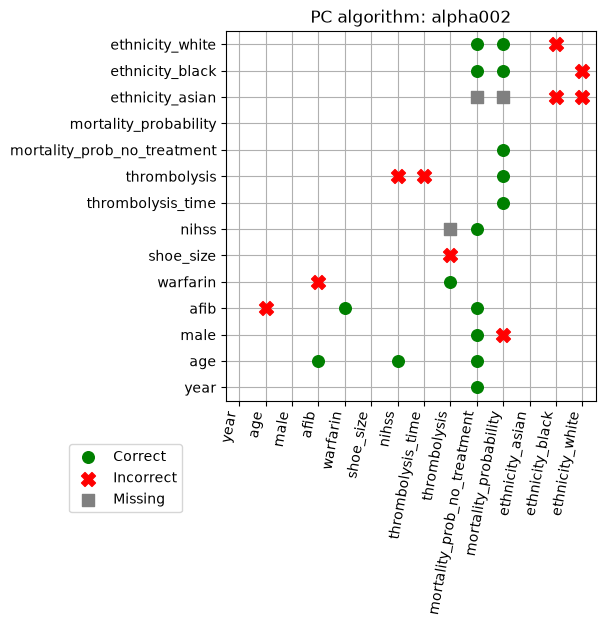

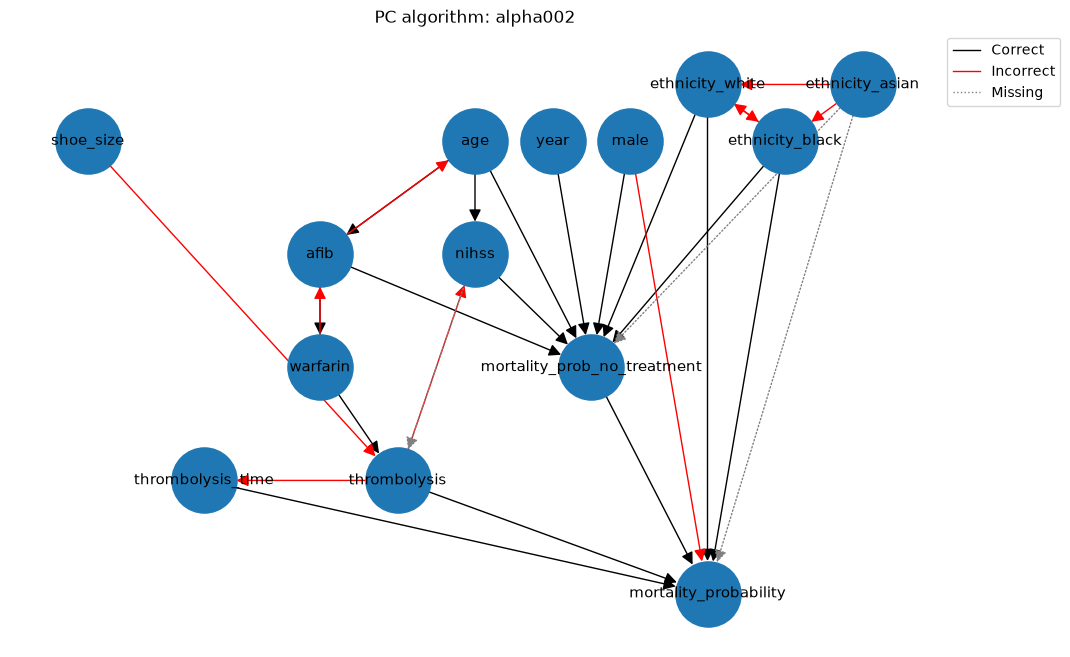

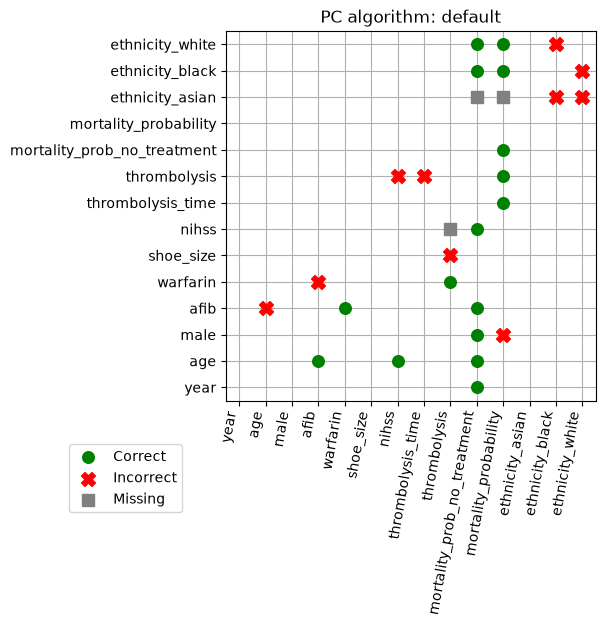

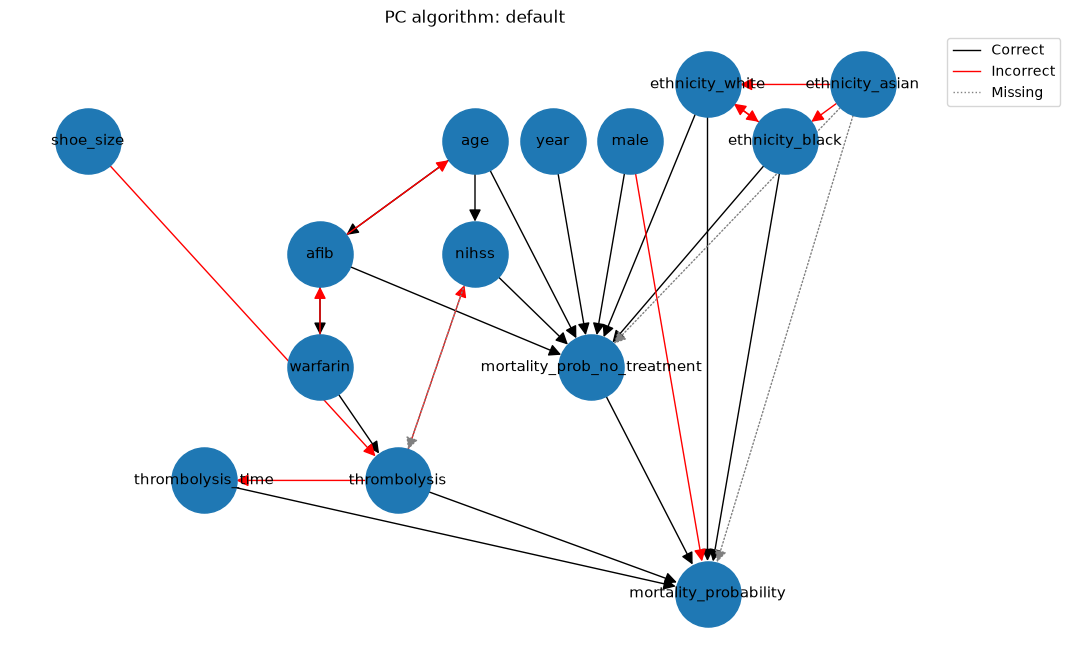

In [14]:
for variation_label, df_effects_disc in dict_disc.items():
    title = f'PC algorithm: {variation_label}'
    # Convert the edge lookup to a graph:
    G_disc = nx.from_pandas_adjacency(df_effects_disc, create_using=nx.DiGraph)
    edges_disc = list(G_disc.edges())
    # Categorise edges as correct, incorrect, or missing:
    edges_dict = categorise_edges_vs_true(edges_disc, edges_true)
    # Plot grid to show linked edges and whether correct:
    plot_matrix_edge_comparison(
        edges_dict, all_features, title=title,
        savename=os.path.join('01_pc', f'matrix_{variation_label}.png')
    )
    # Plot comparative DAG:
    fig, ax = plt.subplots(figsize=(12, 8))
    plot_comparative_dag_networkx(
        G_disc, edges_dict, pos, title=title, ax=ax,
        savename=os.path.join('01_pc', f'dag_{variation_label}.png')
    )